# XGBoost From Scratch

## Part 1: XGBoost - Regression

* Built an XGBoost classifier using `numpy` only. Trained the XGBoost model on the `California Housing` regression task. Reported on the performance predicting unseen test samples. 

In [1]:
import numpy as np

class TreeNode:
    def __init__(self, feature, threshold, value, left, right):
        self.feature = feature
        self.threshold = threshold
        self.value = value
        if value is None:
            self.is_leaf=False
        else:
            self.is_leaf = True
        self.left = left
        self.right = right

class DecisionTree:
    """Base class for a decision tree."""
    def __init__(self, mode, lambda_reg, gamma_reg, max_depth = 5, min_samples = 5):
        self.root = None
        self.stop_reason = None
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.lambda_reg = lambda_reg
        self.gamma_reg = gamma_reg
        
        if mode.lower() not in ['regression', 'classification']:
            raise Exception("Mode parameter must be either 'regression' or 'classification'")
        else:
            self.mode = mode.lower()
    
    def split_condition(self, y, prediction):
        if self.mode == 'regression':
            #MSE
            return np.sum( (y - prediction) **2)
        
        elif self.mode == 'classification':
            if len(y)==0:
                print('EMPTY SPLIT')
                return 0
            #Gini impurity
            u, counts = np.unique(y, return_counts=True)
            p = counts/len(y)
            return 1 - np.sum(p**2)
        
        return None
            
    def leaf_value(self, y, y_hat):
        Gj = np.sum(self.gradient_function(y_hat, y))
        Hj = np.sum(self.hessian_function(y_hat))
        wj = -1* Gj / (Hj + self.lambda_reg)
        
        if self.mode == 'regression':
            return wj
        
        elif self.mode=='classification':
            if len(y)==0:
                print('EMPTY SPLIT')
                return 0
            u, counts = np.unique(y, return_counts=True)
            most_common = u[np.argmax(counts)]
            return most_common
        
    def gradient_function(self, y_hat, y):
        #y_hat should be the prediction of the most recent tree you have grown
        return y_hat - y
    
    def hessian_function(self, y_hat):
        size = len(y_hat)
        return np.ones(size)
        
    def find_best_split(self, X, y, y_hat):
        """
        Find the best feature and threshold to split on given remaining X and y data. 
        """
        best_feature, best_threshold, best_gain = None, None, 0
        
        gradients = self.gradient_function(y_hat, y)
        hessians = np.ones(len(y_hat))
                
        for col_index in range(X.shape[1]):
            feature = X[:,col_index]
            sorted_idx = np.argsort(feature)
            
            x_sorted = feature[sorted_idx]
            g_sorted = gradients[sorted_idx]
            h_sorted = hessians[sorted_idx]
            
            g_summed = np.cumsum(g_sorted)
            h_summed = np.cumsum(h_sorted)
            
            g_total = g_summed[-1]
            h_total = h_summed[-1]
            
            for i in range(self.min_samples, X.shape[0] - self.min_samples):
                
                if x_sorted[i] == x_sorted[i-1]:
                    continue
                    
                threshold = (x_sorted[i - 1] + x_sorted[i]) / 2
                    
                GL = g_summed[i - 1]
                HL = h_summed[i - 1]

                GR = g_total - GL
                HR = h_total - HL   
                
                gain = 0.5 * ((GL**2 / (HL + self.lambda_reg)) + (GR**2 / (HR + self.lambda_reg)) \
                   - ((GL + GR)**2 / (HL + HR + self.lambda_reg))) - self.gamma_reg

                if gain > best_gain: 
                    best_feature, best_threshold, best_gain = col_index, threshold, gain
            
        return best_feature, best_threshold
                
    def fit(self, X, y, y_hat):
        """Build the regression tree."""
        self.root = self._build_tree(X, y, y_hat, 0)
    
    def _build_tree(self, X, y, y_hat, depth):
        """Recursively build the tree."""
        if depth >= self.max_depth: 
            leaf = TreeNode(None, None, self.leaf_value(y, y_hat), None, None)
            return leaf
        
        if X.shape[0] < self.min_samples:
            leaf = TreeNode(None, None, self.leaf_value(y, y_hat), None, None)
            return leaf
            
        best_feature, best_threshold = self.find_best_split(X, y, y_hat)
        
        if best_threshold is None:
            
            leaf = TreeNode(None, None, self.leaf_value(y, y_hat), None, None)
            return leaf
        
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold
        
        left_X, left_y, left_y_hat = X[left_mask], y[left_mask], y_hat[left_mask]
        right_X, right_y, right_y_hat = X[right_mask], y[right_mask], y_hat[right_mask]
        
                
        node = TreeNode(best_feature, best_threshold, None, None, None)
        
        node.left = self._build_tree(left_X, left_y, left_y_hat, depth + 1)
        node.right = self._build_tree(right_X, right_y, right_y_hat, depth + 1)
        
        return node
        
    def print_children(self, node):
        if node is None:
            return

        if node.is_leaf:
            print(f"Leaf: value= {node.value}")
            return
        
        else:
            print(f"NODE:feature={node.feature}, threshold = {node.threshold}")
        
        self.print_children(node.left)
        self.print_children(node.right)
    
    def predict(self, X):
        """Make predictions for X."""
        predictions = []
        
        if self.root is None:
            return "TREE MUST BE FIT BEFORE PREDICTING"
        
        for sample in X:
            node = self.root
            while not node.is_leaf:
                if sample[node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            predictions.append(node.value)   
        
        return predictions

In [2]:
class XGBoost:
    """XGBoost implementation"""
    
    def __init__(self, num_trees, learning_rate, max_depth, min_samples, lambda_reg, gamma_reg):
        self.num_trees = num_trees
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.lambda_reg = lambda_reg
        self.gamma_reg = gamma_reg
        self.trees = None
        self.f0 = None
        
    def loss_function(y_hat, y):
        return np.sum(0.5 * (y - y_hat) ** 2)
    
    def fit(self, X, y):
        """Train the XGBoost model"""
        trees = []
        f0 = np.mean(y)
        
        y_hat = np.full(len(y), f0)
        
        self.f0 = f0
        
        for m in range(self.num_trees): #num_trees = T
            WeakLearner = DecisionTree('regression',self.lambda_reg, self.gamma_reg, max_depth = self.max_depth, min_samples = self.min_samples)
            WeakLearner.fit(X, y, y_hat)
            fm_x = self.learning_rate * np.array(WeakLearner.predict(X))
            y_hat = y_hat + fm_x
            trees.append(WeakLearner)
        
        self.trees = trees
    
    def predict(self, X):
        """Make predictions"""
        if self.trees is None or self.f0 is None:
            return "Model must be fit before prediction!"
        
        final_prediction = np.full(len(X), self.f0)
        
        for tree in self.trees:
            pred_tree = np.array(tree.predict(X))
            final_prediction += self.learning_rate * pred_tree
            
        return final_prediction
    
    def print_hyperparams(self):
        params = [self.num_trees, self.learning_rate, self.max_depth, self.min_samples, self.lambda_reg, self.gamma_reg]
        param_names = ['num trees', 'learning rate', 'max tree depth', 'min leaf samples', 'lambda regularization constant', 'gamma reguralization constant']
        for index, i in enumerate(params):
            print(f'{param_names[index]}: {i}\n')

    
    # Probabilities for classification :) - The Bonus task
    def predict_proba(self, X):
        """Predict probabilities for binary classification"""
        pass


In [3]:
from sklearn.datasets import fetch_california_housing
import numpy as np
# Load California Housing data
data = fetch_california_housing()
X = data.data
y = data.target

In [4]:
xgboost = XGBoost(num_trees = 100, learning_rate = 0.3, max_depth = 6, min_samples=10, lambda_reg = 1, gamma_reg = 0.1)

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [6]:
xgboost.fit(X_train, y_train)

In [7]:
y_pred = xgboost.predict(X_test)

In [8]:
test_mse = np.mean((y_pred-y_test)**2)

print(f'XGBOOST MODEL TRAINED ON FOLLOWING HYPER PARAMETERS: \n')
xgboost.print_hyperparams()
print(f'ACHIEVED MEAN SQUARED REGRESSION ERROR OF {test_mse.round(4)} ON {len(y_test)} UNSEEN TEST SAMPLES')

XGBOOST MODEL TRAINED ON FOLLOWING HYPER PARAMETERS: 

num trees: 100

learning rate: 0.3

max tree depth: 6

min leaf samples: 10

lambda regularization constant: 1

gamma reguralization constant: 0.1

ACHIEVED MEAN SQUARED REGRESSION ERROR OF 0.2186 ON 4128 UNSEEN TEST SAMPLES


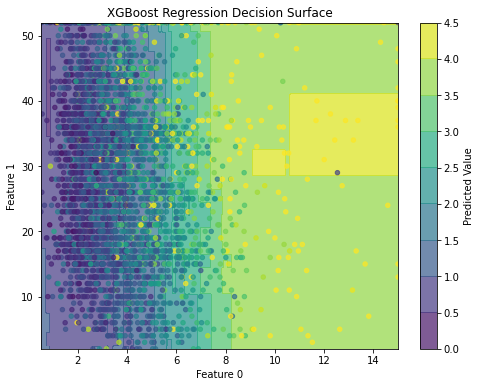

In [20]:
import matplotlib.pyplot as plt
import numpy as np

f1, f2 = 0, 1  # feature indices

# Create meshgrid
xx, yy = np.meshgrid(
    np.linspace(X_test[:, f1].min(), X_test[:, f1].max(), 300),
    np.linspace(X_test[:, f2].min(), X_test[:, f2].max(), 300)
)

# Full-dimensional grid (baseline = mean feature vector)
X_ref = X_test.mean(axis=0)
grid = np.tile(X_ref, (xx.size, X_test.shape[1]))

grid[:, f1] = xx.ravel()
grid[:, f2] = yy.ravel()

# Predict (continuous values)
Z = np.array(xgboost.predict(grid))
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

# Continuous decision surface
contour = plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.7)
plt.colorbar(contour, label="Predicted Value")

# Scatter true targets
plt.scatter(
    X_test[:, f1],
    X_test[:, f2],
    c=y_test,
    cmap='viridis',
    alpha = 0.7,
    s=20
)

plt.xlabel(f'Feature {f1}')
plt.ylabel(f'Feature {f2}')
plt.title("XGBoost Regression Decision Surface")
plt.show()

In [21]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def plot_feature_importance(model, model_name, color, X, y, feature_names):
    baseline_mse = mse(y, model.predict(X))

    importances = []

    for i in range(X.shape[1]):
        X_permuted = X.copy()

        shuffled = X_permuted[:, i].copy()
        np.random.shuffle(shuffled)

        X_permuted[:, i] = shuffled

        permuted_mse = mse(y, model.predict(X_permuted))

        importances.append(permuted_mse - baseline_mse)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    plt.figure(figsize=(10, 6))

    plt.barh(
        range(len(importance_df)),
        importance_df["Importance"], 
        color = color
    )

    plt.yticks(
        range(len(importance_df)),
        importance_df["Feature"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Feature Importance")
    plt.ylabel("Synthetic Feature Index")
    plt.title(f"{model_name} Feature Importance")

    plt.tight_layout()
    plt.show()

In [25]:
import pandas as pd

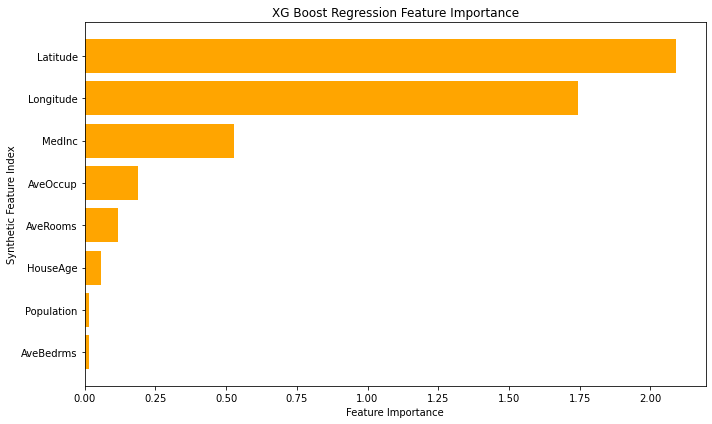

In [26]:
plot_feature_importance(xgboost, "XG Boost Regression", "orange", X_test, y_test, data.feature_names)